In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sqlite3
import folium
import enhanced_cleaning as ec

In [3]:

from pathlib import Path
df_cleaned = ec.clean(
    input_path=Path(r"C:\Users\H A S E E B\Documents\gdg_hackathon\wpdx_enhanced.csv"),
    output_path=Path(r"C:\Users\H A S E E B\Documents\gdg_hackathon\wpdx_cleaned.csv"),
    report_path=Path(r"C:\Users\H A S E E B\Documents\gdg_hackathon\wpdx_report.txt")
)

✓ Cleaned 21,953 rows → C:\Users\H A S E E B\Documents\gdg_hackathon\wpdx_cleaned.csv
✓ Dropped  0 rows
✓ Report   → C:\Users\H A S E E B\Documents\gdg_hackathon\wpdx_report.txt


In [3]:
df = pd.read_csv(r"C:\Users\H A S E E B\Documents\gdg_hackathon\wpdx_cleaned.csv")
df.head()

,lat_deg,lon_deg,status_id,report_date,source,water_source_clean,water_tech_clean,clean_country_id,clean_country_name,clean_adm1,...,distance_to_primary,distance_to_secondary,distance_to_tertiary,distance_to_city,distance_to_town,is_urban,days_since_report,staleness,report_year,functional_status
0,0.212005,34.615833,Yes,2023-10-30,Evidence Action,Protected Well,Motorized Pump - Electric,KEN,Kenya,Kakamega,...,8529.682780,8015.539423,934.385159,16888.145393,1003.744243,False,769.0,78.474305,2023,Non-Functional
1,0.212567,34.616543,Yes,2023-10-30,Evidence Action,Protected Well,Motorized Pump - Electric,KEN,Kenya,Kakamega,...,8445.447017,8113.309567,862.146783,16789.312947,962.362617,False,769.0,78.474305,2023,Non-Functional
2,0.222063,34.601463,Yes,2023-11-16,Evidence Action,Protected Well,Motorized Pump - Electric,KEN,Kenya,Kakamega,...,8199.685589,7059.498972,571.407442,17867.615291,1410.202842,False,752.0,78.895948,2023,Non-Functional
3,0.222362,34.604015,Yes,2023-11-18,Evidence Action,Protected Well,Motorized Pump - Electric,KEN,Kenya,Kakamega,...,8026.871554,7335.666440,654.036253,17592.384527,1131.781048,False,750.0,78.945701,2023,Non-Functional
4,0.023602,34.777866,Yes,2023-09-11,Evidence Action,Protected Well,Motorized Pump - Electric,KEN,Kenya,Vihiga,...,11662.773919,6267.677047,543.240978,14235.448645,5417.123498,False,818.0,77.271546,2023,Non-Functional


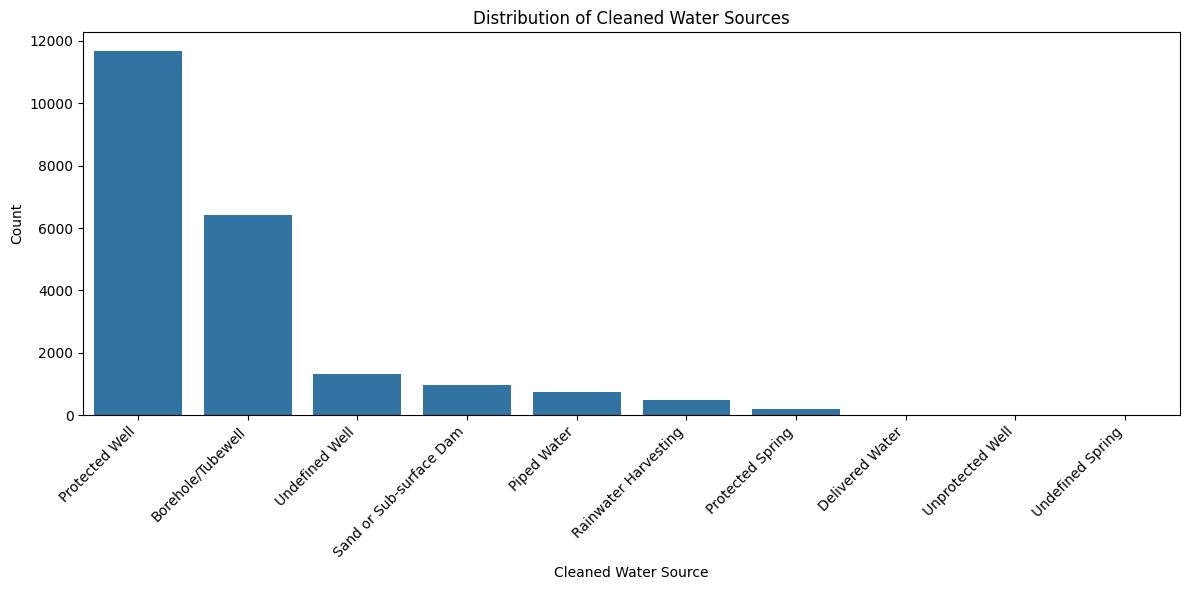

In [4]:
#count number of water_source_clean and visualize exclude nan,  align x-axis labels 

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='water_source_clean', order=df['water_source_clean'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Cleaned Water Sources')
plt.xlabel('Cleaned Water Source')
plt.ylabel('Count')
plt.tight_layout()
plt.show()





In [2]:
%pip install earthengine-api

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import ee
print(ee.__version__)

1.7.16


In [6]:
import importlib, sys

# Add analysis folder to path
sys.path.insert(0, r'C:\Users\H A S E E B\Documents\gdg_hackathon')

import gee_water_analysis as gwa
import gee_population_impact as gpi
importlib.reload(gwa)
importlib.reload(gpi)

KEY    = r'C:\Users\H A S E E B\Documents\gdg_hackathon\gee-key.json'
CSV    = r'C:\Users\H A S E E B\Documents\gdg_hackathon\wpdx_enhanced.csv'
OUT    = r'C:\Users\H A S E E B\Documents\gdg_hackathon'

gwa.run(key_file=KEY, csv_path=CSV, out_dir=OUT)
gpi.run(key_file=KEY, csv_path=CSV, out_dir=OUT)

print("✅ Done — hard refresh browser now (Ctrl+Shift+R)")

✓ GEE authenticated
Generating tile URLs...
✓ Tile URLs generated
✓ Tile URLs → gee_surface_water_tiles.json
✓ Loaded 21,953 water points from C:\Users\H A S E E B\Documents\gdg_hackathon\wpdx_enhanced.csv

Running proximity analysis (500m threshold)...
  Processed 500 / 21,953 points...
  Processed 1,000 / 21,953 points...
  Processed 1,500 / 21,953 points...
  Processed 2,000 / 21,953 points...
  Processed 2,500 / 21,953 points...
  Processed 3,000 / 21,953 points...
  Processed 3,500 / 21,953 points...
  Processed 4,000 / 21,953 points...
  Processed 4,500 / 21,953 points...
  Processed 5,000 / 21,953 points...
  Processed 5,500 / 21,953 points...
  Processed 6,000 / 21,953 points...
  Processed 6,500 / 21,953 points...
  Processed 7,000 / 21,953 points...
  Processed 7,500 / 21,953 points...
  Processed 8,000 / 21,953 points...
  Processed 8,500 / 21,953 points...
  Processed 9,000 / 21,953 points...
  Processed 9,500 / 21,953 points...
  Processed 10,000 / 21,953 points...
  Proce

In [7]:
import subprocess, os, time

# Serve from outputs/ so the HTML and JSON are in the same place
os.chdir(r'C:\Users\H A S E E B\Documents\gdg_hackathon')
subprocess.Popen(['python', '-m', 'http.server', '8000'])
time.sleep(1)
print("✅ Server running — open: http://localhost:8000/Hydro.html")

✅ Server running — open: http://localhost:8000/Hydro.html
